В файле **WIPO-GII_2022.xlsx** содержаться данные по странам о показателях, используемых для расчета Global Innovation Index за 2022 год.

### В файле следующие переменные:
- Country
- Business environment
- Business sophistication index
- Citable documents H-index
- Creative goods and services
- Creative goods exports, % total trade
- Creative outputs index
- Cultural and creative services exports, % total trade
- Domestic market scale, bn PPP
- Ecological sustainability
- Expenditure on education, % GDP
- Firms offering formal training, %
- General infrastructure
- Government effectiveness
- Government's online service
- Graduates in science and engineering, %
- Gross expenditure on R&D, % GDP
- High-tech exports, % total trade
- High-tech imports, % total trade
- High-tech manufacturing, %
- Human capital and research index
- Information and Communications Technology access
- Information and Communications Technology services exports, % total trade
- Information and Communications Technology services imports, % total trade
- Information and Communications Technology use
- Infrastructure index
- Intangible assets
- Joint venture/strategic alliance deals/bn PPP GDP
- Knowledge absorption
- Knowledge and technology outputs index
- Knowledge workers
- Knowledge-intensive employment, %
- Logistics performance
- Market sophistication index
- Mobile app creation/bn PPP GDP
- Online creativity
- PISA scales in reading, maths and science
- Political and operational stability
- Political environment
- Pupil-teacher ratio, secondary
- QS university ranking average score of top 3 universities
- Research and development (R&D)
- Scientific and technical articles/bn PPP GDP
- Software spending, % GDP
- Tertiary education
- Tertiary enrolment, % gross
- University-industry R&D collaboration
- Region
- Region2
- Euro area
- European Union
- OECD members
- Least developed countries
- Income
- High income

In [ ]:
pip install yellowbrick

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import product
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import scipy.cluster.hierarchy as sch


In [ ]:
df = pd.read_excel('WIPO-GII_2022.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 55 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Country                                                                         139 non-null    object 
 1   Business environment_2022                                                       132 non-null    float64
 2   Business sophistication index_2022                                              132 non-null    float64
 3   Citable documents H-index_2022                                                  132 non-null    float64
 4   Creative goods and services_2022                                                132 non-null    float64
 5   Creative goods exports, % total trade_2022                                      132 non-null    float64
 6   Creative outputs i

1. Выберите не менее 5 интересующих Вас метрических переменных для последующего проведения кластерного анализа данных. Приведите аргументы в пользу возможности их использования для кластеризации.

Gross expenditure on R&D, % GDP_2022 - доля внутренних затрат на исследования и разработки, показывает насколько сильно страна вкладывается в инновации. ( Научные инвестиции )

Ecological sustainability_2022 - сводный индекс экологической устойчивости. Оценивает ресурсную эффективность, качество окружающей среды. ( Экологический аспект)

Pupil-teacher ratio, secondary_2022 - коэффициент учащихся на одного учителя в среднем образовании. Показывает нагрузку на систему образования

Political and operational stability_2022 - индикатор политической стабильности

Creative goods exports, % total trade_2022 - доля экспорта креативных товаров в общем экспорте страны. ( Културный аспект )

Мы выбрали эти признаки, потому что они отображают разные аспекты страны, вероятно не будут сильно коррелировать, что поможет провести более четкий кластерный анализ и разделить на более конкретные группы.

In [ ]:
selected_variables = [
    'Gross expenditure on R&D, % GDP_2022',
    'Ecological sustainability_2022',
    'Pupil-teacher ratio, secondary_2022',
    'Political and operational stability_2022',
    'Creative goods exports, % total trade_2022'
]

print("Выбранные переменные для кластеризации:")
for i, var in enumerate(selected_variables, 1):
    print(f"{i}. {var}")

Выбранные переменные для кластеризации:
1. Gross expenditure on R&D, % GDP_2022
2. Ecological sustainability_2022
3. Pupil-teacher ratio, secondary_2022
4. Political and operational stability_2022
5. Creative goods exports, % total trade_2022


Проверим распределение

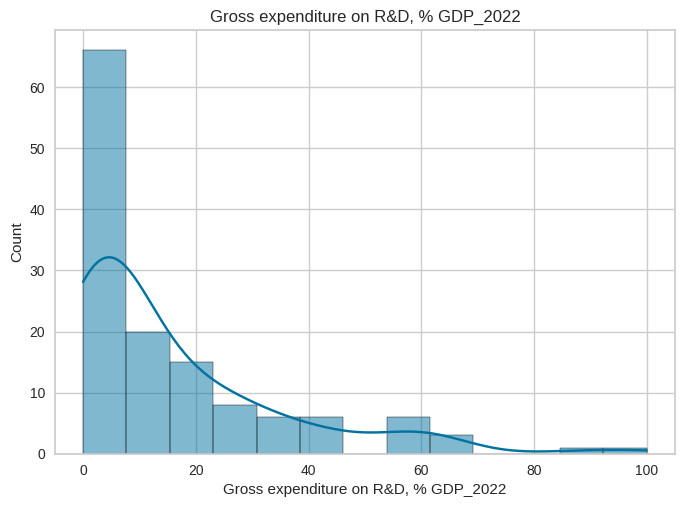

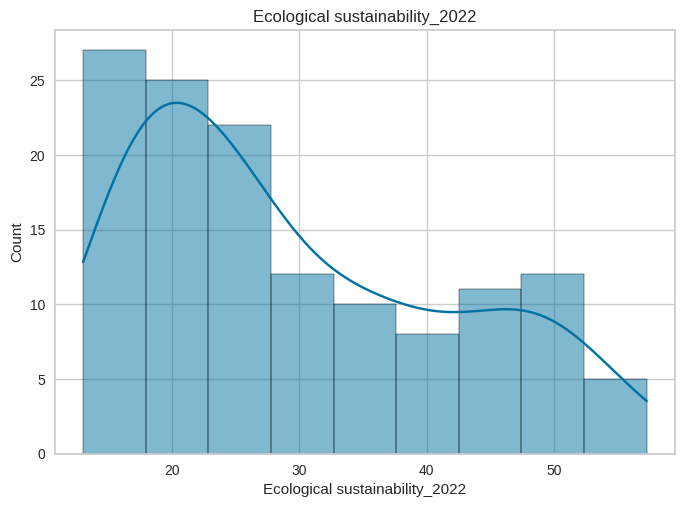

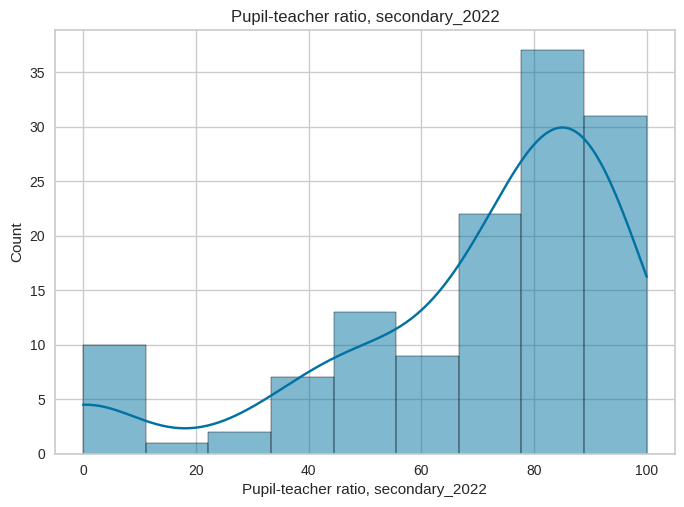

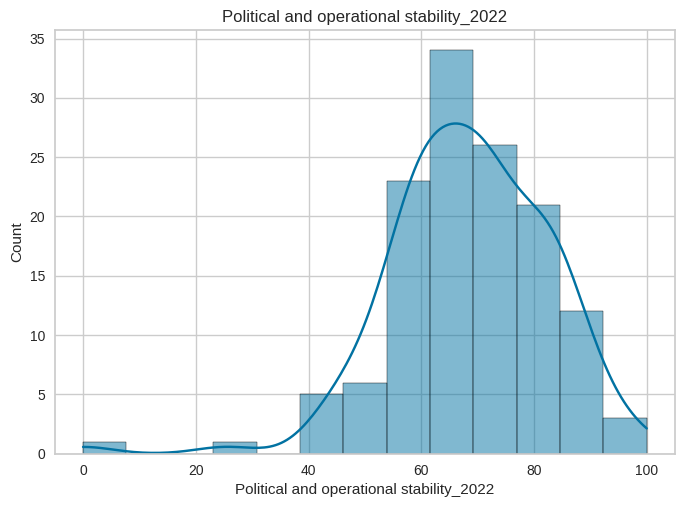

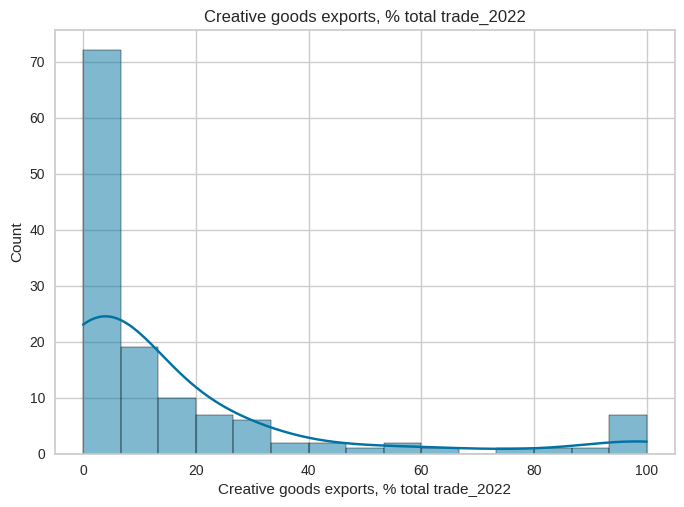

In [ ]:
for col in selected_variables:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

Видим, что распределение не нормальное, поэтому в данном случае стоит проверять корреляцию с помощью Спирмена.

Проверим корреляции

In [ ]:
cluster_data_clean = df.dropna()
cluster_data_clean[selected_variables].corr(method = "spearman")

,"Gross expenditure on R&D, % GDP_2022",Ecological sustainability_2022,"Pupil-teacher ratio, secondary_2022",Political and operational stability_2022,"Creative goods exports, % total trade_2022"
"Gross expenditure on R&D, % GDP_2022",1.000000,0.580392,0.409203,0.665057,0.600228
Ecological sustainability_2022,0.580392,1.000000,0.504420,0.641676,0.531035
"Pupil-teacher ratio, secondary_2022",0.409203,0.504420,1.000000,0.536667,0.340988
Political and operational stability_2022,0.665057,0.641676,0.536667,1.000000,0.497558
"Creative goods exports, % total trade_2022",0.600228,0.531035,0.340988,0.497558,1.000000


Все корреляции в умеренных пределах, поэтому можно выполнять кластеризацию.
Также как аргумент в пользу возможности их использования для кластеризации, можно использовать то, что они охватывают все основные сферы развития, т.е. переменные разнообразны и при этом каждая имеет ясный смысл, значит в итоге кластеризачии мы получим значимые на практике выводы.

2. Выберите подходящий алгоритм кластеризации и обоснуйте свой выбор. Определите число кластеров, объясните своё решение. Опишите получившиеся кластеры с помощью описательной статистки. Нужно не просто рассчитать статистики в таблицах, но детально описать полученные результаты. Дайте названия кластерам и обоснуйте их.

Делаем стандартизацию

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data_clean[selected_variables])
X_scaled

array([[-0.75249131, -0.46729647, -0.87614162, -0.08267857, -0.60974671],
       [ 1.0705289 ,  1.45851642,  0.61339009,  0.9415724 ,  3.22312996],
       [ 0.09207173, -0.32857266,  0.18191365, -0.59833595,  0.02842533],
       [ 0.1178206 ,  2.19293659,  0.67717356,  0.9415724 ,  3.22312996],
       [ 0.01997488, -1.20171664, -0.13325175, -1.62258691, -0.57514702],
       [ 3.7484117 , -0.21432952,  0.5758704 ,  1.06872079,  1.68152159],
       [-0.80913883, -0.89162812,  0.06935458,  0.29876662,  0.50897657],
       [-0.68039446, -0.96507014, -0.95868494, -1.75679911, -0.30603833],
       [ 0.22596587, -1.0874735 , -2.60579935, -0.34403916, -0.4521259 ],
       [ 0.04572376,  1.70332315,  0.66591766,  1.06872079,  2.54266941],
       [ 0.21566632, -0.2388102 ,  0.2119294 , -0.47118755,  0.57048713],
       [-0.80913883,  1.16474835, -0.90990934, -4.8366158 , -0.61743553],
       [-0.78853973, -0.59786006, -0.91366131, -0.47118755, -0.61743553],
       [-0.80913883, -1.12827462, -0.0

Метод K-means выбран как наиболее подходящий для кластерного анализа так как:

  - Все переменные числовые и непрерывные

  - Данные стандартизированы (одинаковые масштабы)

  - Предполагаем, что кластеры будут иметь форму сферы, а именно страны с разным уровнем развития

  - Размер данных (139 стран) оптимален для K-means

  - Нужны четкие, интерпретируемые группы стран

  - Удобно можно получить "средние профили" кластеров (центроиды)

Определим количество кластеров:

In [ ]:
for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(X_scaled)
    print('Число кластеров: {}, индекс {}'.format(k, calinski_harabasz_score(X_scaled, labels)))

Число кластеров: 2, индекс 80.29812957382971
Число кластеров: 3, индекс 60.41067464263156
Число кластеров: 4, индекс 64.3596452308104
Число кластеров: 5, индекс 56.29966978363032
Число кластеров: 6, индекс 54.22739062412923
Число кластеров: 7, индекс 50.45737589027324
Число кластеров: 8, индекс 55.44464520779942
Число кластеров: 9, индекс 48.51160958286187
Число кластеров: 10, индекс 44.70170789303275
Число кластеров: 11, индекс 53.52743985236417
Число кластеров: 12, индекс 53.82570987001843
Число кластеров: 13, индекс 52.57658808119053
Число кластеров: 14, индекс 51.2909283879257


Пользуемся методом локтя:

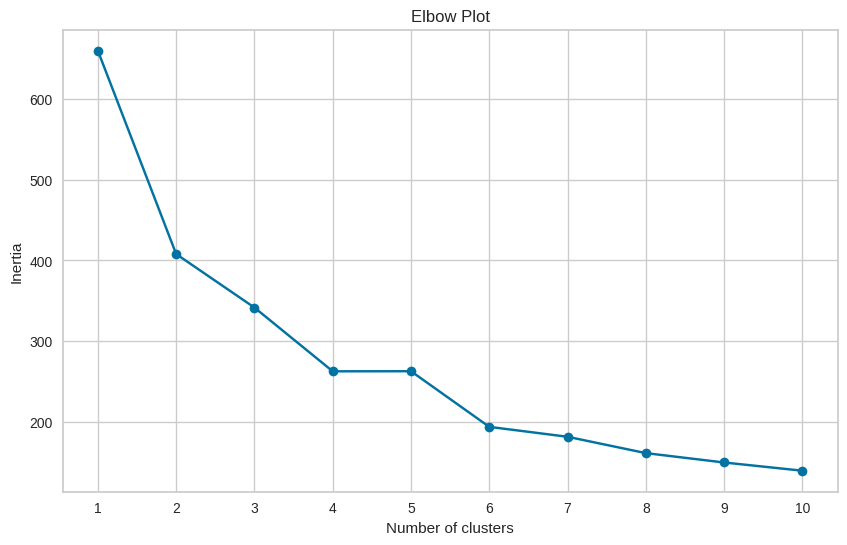

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

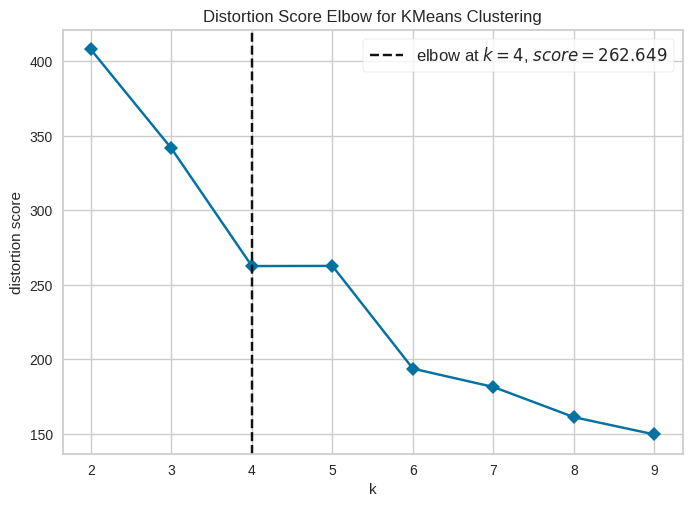

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X_scaled)
visualizer.show()
plt.show()

Смотрим коэффициент силуэта:

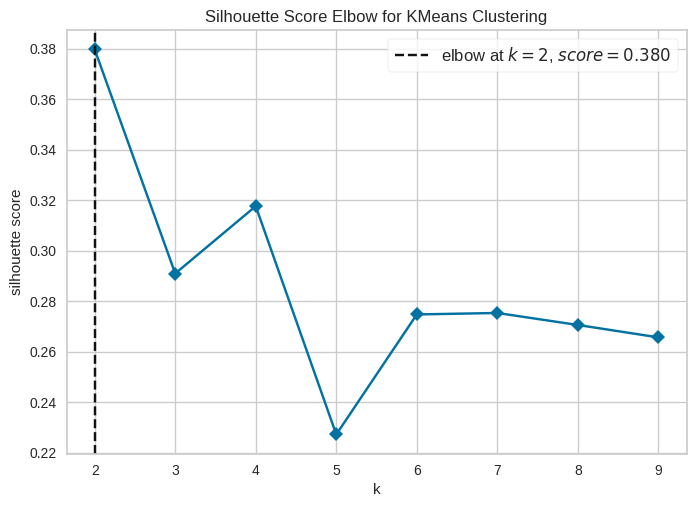

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X_scaled)
visualizer.show()
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=4).fit_predict(X_scaled)

In [ ]:
cluster_data_clean['Clusters'] = kmeans_model
cluster_data_clean.head()

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,University-industry R&D collaboration_2022,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income,Clusters
0,Cote d'Ivoire,48.3,21.8,5.1,1.2,0.3,6.0,2.1,3.4,23.7,...,38.5,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,0,middle income,0,0
1,Czechia,42.1,46.2,30.4,40.6,100.0,29.9,15.3,10.3,47.3,...,59.1,Europe & Central Asia,Europe,0,1,1,0,high income,1,3
2,"Egypt, Arab Rep.",45.0,20.4,18.0,9.1,16.9,14.1,0.0,30.9,25.4,...,47.0,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0,0
3,"Hong Kong SAR, China",69.7,46.7,38.4,47.4,100.0,53.2,3.0,10.8,56.3,...,62.9,East Asia & Pacific,Asia-Pacific,0,0,0,0,high income,1,3
4,"Iran, Islamic Rep.",13.3,18.6,22.1,4.0,1.2,31.8,4.2,26.6,14.7,...,27.7,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0,0


In [ ]:
cluster_data_clean['Clusters'].value_counts()

,count
Clusters,
0,58
1,39
2,23
3,12


Объяснить свое решение почему 4:
Анализ индекса Калински-Харабаса и метод локтя и коэффициент силуэта показали, что значение достигает пика при 1 кластере, что не дает нам никакой дополнительной информации. По методу локтя мы видим что начиная с 4х кластеров инерция начинает меньше уменьшаться. Также расница в количестве элементов в кластерах не слишком большая.

In [ ]:
cluster_data_clean.groupby('Clusters')[selected_variables].mean(numeric_only=True)

,"Gross expenditure on R&D, % GDP_2022",Ecological sustainability_2022,"Pupil-teacher ratio, secondary_2022",Political and operational stability_2022,"Creative goods exports, % total trade_2022"
Clusters,,,,,
0,5.310345,23.020690,74.868966,64.048276,5.968966
1,35.774359,42.569231,85.710256,81.023077,17.212821
2,4.939130,20.395652,23.234783,55.173913,2.134783
3,21.433333,34.983333,79.008333,74.533333,88.883333


In [ ]:
df[selected_variables].mean()

,0
"Gross expenditure on R&D, % GDP_2022",15.712121
Ecological sustainability_2022,29.426515
"Pupil-teacher ratio, secondary_2022",69.451515
Political and operational stability_2022,68.470455
"Creative goods exports, % total trade_2022",16.160606


# Описание:

**Кластер 0: Страны с низким уровнем инновационного развития**
Для стран этого кластера характерны низкие показатели по всем ключевым переменным, описывающим инновационное развитие, но умеренная нагрузка на систему образования:

Низкие значения затрат на исследования и разработки указывают на слабое развитие научно-технологической сферы.

Низкие показатели экологической устойчивости и доли креативных товаров в экспорте, то есть слабо развиты креативные отрасли и не уделяется должное внимание экологии.

Политическая и операционная стабильность умеренная, но не высокая.

Соотношение учащихся и учителей низкое, что указывает на умеренную (благоприятную) нагрузку на систему образования.

**Кластер 1: страны-экспортёры креативных товаров**

Для стран этого кластера характерны очень высокие показатели доли креативных товаров в экспорте, что указывает на лидирующую роль творческих индустрий в экономике.

затраты на R&D остаются умеренными — эти страны развиваются не столько за счёт науки, сколько за счёт коммерциализации идей и креативных продуктов.

**Кластер 2: высокоразвитые инновационные экономики**

Наивысшие инвестиции в R&D среди всех групп, что отражает сильную ориентацию на научно-технический прогресс и технологические стартапы.

Экологическая устойчивость  и политическая стабильность — также максимальные значения, показывающие зрелость институтов и внимание к устойчивому развитию.

Соотношение учеников и учителей довольно высокое — признак массовости образования и перегруженности системы.

Доля креативных товаров в экспорте  умеренная — экономика ориентирована на технологии и инновации, а не на культурный экспорт.

**Кластер 3: страны со слабым инновационным потенциалом и проблемами в образовании**

Эти страны демонстрируют минимальные значения по большинству ключевых показателей.

Инвестиции в R&D и доля креативных товаров в экспорте одни из самых низких, что указывает на отсутствие развитой инновационной экосистемы.

Экологическая устойчивость также слабая/

Политическая стабильность чуть выше, чем у кластера 0, однако Pupil–teacher ratio свидетельствует о высокой нагрузке на систему образования и ограниченной доступности качественного обучения.




3. Проведите апостериорный анализ данных на основе категориальных переменных датасета. Например, рассмотрите как распределены страны разных регионов по кластерам или в какие кластеры в основном попали страны-члены ОЭСР?

Строим перекрестную таблицу, чтобы посмотреть процентное распределение кластера в каждом регионе

In [ ]:
pd.crosstab(cluster_data_clean['Region'], cluster_data_clean['Clusters'], normalize='index') * 100

Clusters,0,1,2,3
Region,,,,
East Asia & Pacific,29.411765,23.529412,11.764706,35.294118
Europe & Central Asia,25.531915,63.829787,2.127660,8.510638
Latin America & Caribbean,72.222222,0.000000,22.222222,5.555556
Middle East & North Africa,62.500000,12.500000,18.750000,6.250000
North America,0.000000,100.000000,0.000000,0.000000
South Asia,60.000000,0.000000,40.000000,0.000000
Sub-Saharan Africa,55.555556,3.703704,40.740741,0.000000


Добавляем гистограмму для наглядности

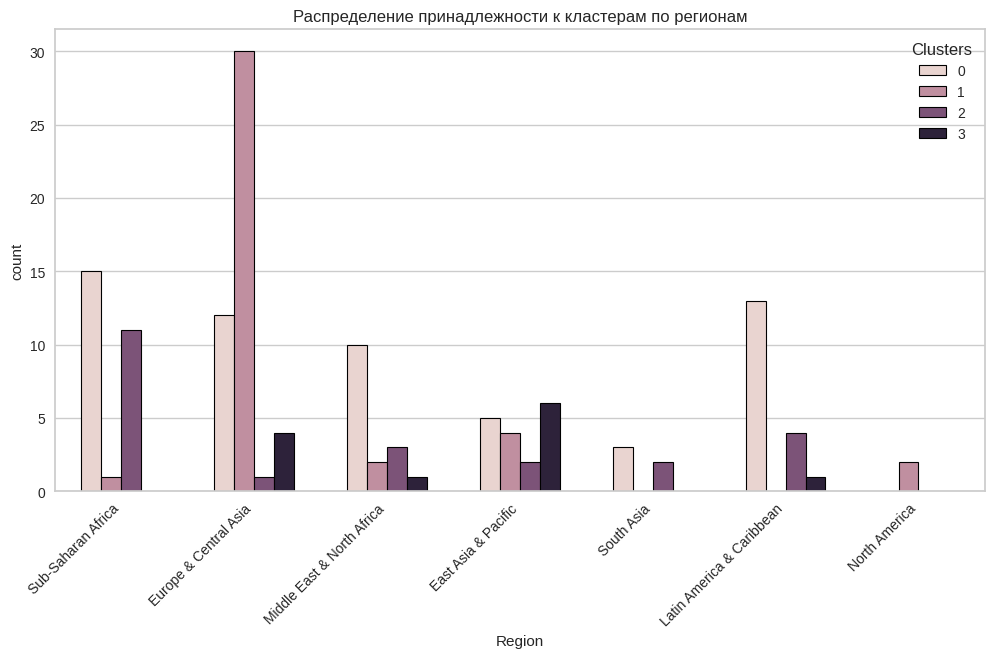

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Region', hue='Clusters', data=cluster_data_clean, width = 0.6, edgecolor = "black", linewidth = 0.8)
plt.title('Распределение принадлежности к кластерам по регионам')
plt.xticks(rotation=45, ha='right')
plt.show()

Находим исключения в Латинской Америке и Карибском регионе

In [ ]:
cluster_data_clean[(cluster_data_clean["Region"] == "Latin America & Caribbean") & (cluster_data_clean["Clusters"].isin([1, 2]))]

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,University-industry R&D collaboration_2022,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income,Clusters
118,Argentina,44.3,31.2,27.8,17.0,1.1,24.2,30.0,23.4,25.3,...,38.0,Latin America & Caribbean,Americas,0,0,0,0,middle income,0,2
127,El Salvador,29.0,23.1,1.6,4.0,7.8,12.0,0.1,1.2,24.7,...,29.8,Latin America & Caribbean,Americas,0,0,0,0,middle income,0,2
132,Nicaragua,14.5,23.7,3.0,9.6,9.6,7.5,0.0,0.7,19.8,...,22.4,Latin America & Caribbean,Americas,0,0,0,0,middle income,0,2
138,Uruguay,64.2,28.6,10.4,17.6,0.8,13.5,23.5,1.7,32.8,...,42.7,Latin America & Caribbean,Americas,0,0,0,0,high income,1,2


Находим исключения в Ближнем Востоке и Северной Африке

In [ ]:
cluster_data_clean[(cluster_data_clean["Region"] == "Middle East & North Africa") & (cluster_data_clean["Clusters"].isin([1, 2]))][["Country", "Clusters"]]

,Country,Clusters
12,"Yemen, Rep.",2
42,Algeria,2
44,Iraq,2
45,Israel,1
79,Malta,1


Видно, что почти все страны в Африке принадлежат к 0 или 3 кластеру (низкий уровень инновационного развития).

В Европе & Центральной Азии Большинство стран высокоразвитые инновационные экономики ( 2 кластер ), достаточное количество стран-экспортеров культурных товаров ( 8.5% 1-го кластера ), Но также много стран с слабым инновационным потенциалом и проблемами в образовании (25 % 3-го кластера), хотя мало (2%) стран с проблемами в инновациях и хорошей нагрузкой на образование (0 кластер).

Большинство стран ближнего востока и Северной Африки имеют проблемы с инновационным развитием и образованием ( 62.5% относятся к 3 кластеру, 19% к 0-му кластеру ), но существуют 3 исключения, которые относятся к 1 или 2 кластерам (это Израиль, ОАЭ и Мальта).

В Восточной Азии и тихоокеансокм регионе страны поделились на кластеры почти равномерно: 0-го кластера только 2 страны, 3-го кластера 5 стран, в сумме 1-го и 2-го кластера 10 стран, но первого на 2 больше, чем второго. То есть, в развитых странах этих регонов больше стран, в экспорте которых лидируют культурный товар, нежели тех, которые ориентированны на технологии и инновации.

Все страны Южной Азии принадлежат к странам с слабым инновационным развитием, но поделены пополам между 0 и 3 кластерами ( в половине стран нагрузка на систему образования благоприятная )

Аналогичная ситуация с Латинской Америкой и Каррибским регионом за исключением двух стран, которые принадлежат к 1 и 2 кластерам. ( Панама и Коста-Рика ), но в данном случае число стран 3 кластера (плохая нагрузка на образовательную систему) в 2 раза больше стран 0 кластера.

Все страны Северной Америки ( Канада и США ) - высокоразвитые инновационные экономики ( 2 кластер ).


Строим перекрестную таблицу и гистограмму, чтобы увидеть процентное распределение кластеров по среди стран входящих и не входящих в ОЭСР.

In [ ]:
pd.crosstab(cluster_data_clean['OECD members'], cluster_data_clean['Clusters'], normalize='index') * 100

Clusters,0,1,2,3
OECD members,,,,
0,57.446809,11.702128,23.404255,7.446809
1,10.526316,73.684211,2.631579,13.157895


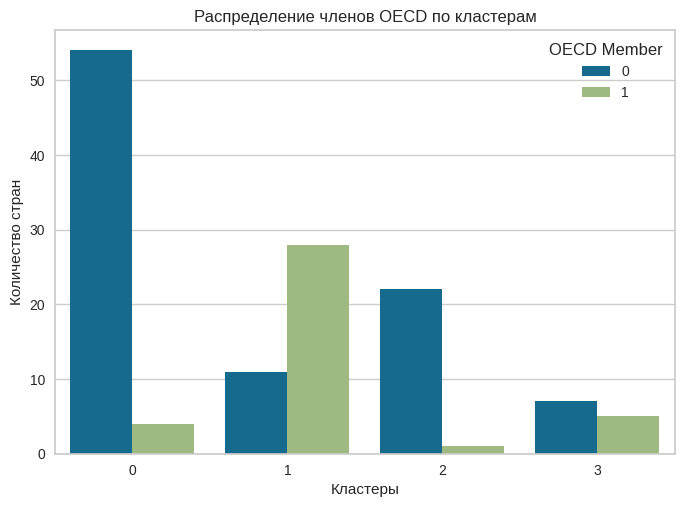

In [ ]:
sns.countplot(x='Clusters', hue='OECD members', data=cluster_data_clean)
plt.title('Распределение членов OECD по кластерам')
plt.xlabel('Кластеры')
plt.ylabel('Количество стран')
plt.legend(title='OECD Member')
plt.show()

In [ ]:
cluster_data_clean[(cluster_data_clean["OECD members"] == 1) & (cluster_data_clean["Clusters"].isin([0, 3]))][["Country", "Clusters"]]

,Country,Clusters
1,Czechia,3
10,Slovak Republic,3
11,Turkiye,0
72,Hungary,3
85,Poland,3
122,Chile,0
123,Colombia,0
124,Costa Rica,0
131,Mexico,3


Видно, что в менее развитых странах ( 0 и 3 кластеры ) почти все страны не являются членами ОЭСР, за исключением 9 стран (25% от всех стран ОЭСР): Чехия, Словацкая Республика, Турция, Венгрия, Польша, Австралия, Чили, Колумбия и Мексика. Это показывает, что членство в ОЭСР напрямую связано с уровнем экономического и инновационного развития страны. Страны — члены организации, как правило, обладают более высоким научным потенциалом, устойчивой политической системой и развитыми креативными отраслями.

4. Почему получилась именно такая кластерная структура? Полученные результаты соответствуют вашем изначальным предположениям или оказались неожиданными?

Такая кластерная структура получилась потому, что страны различаются по уровню экономического и инновационного развития.
В реальном мире существуют как развитые государства, активно инвестирующие в науку и технологии, так и страны с ограниченными ресурсами и слабой инновационной активностью.
Кроме того, часть государств делает акцент на креативных индустриях, а другие — на научных и технологических разработках.

Остающие по развитию страны делятся относительно нагруженности на систему образования, что тоже имеет смысл, так как менее развитые страны можно поделить относительно потенциала к инновационному развитию.


Полученные результаты соответствуют ожиданиям: наиболее развитые страны сгруппировались вместе, а менее развитые образовали отдельные кластеры.

# Дополнительно

Теперь проведем кластерный анализ с помощью DBSCAN и иерархического алгоритма и сравним полученные результаты с анализом через k-means

Сначала сделаем иерархическим методом:

Для нахождения числа кластеров будем использовать коэффициент силуэта, так как метод локтя основан на расстоянии до центров ( для k-means ).

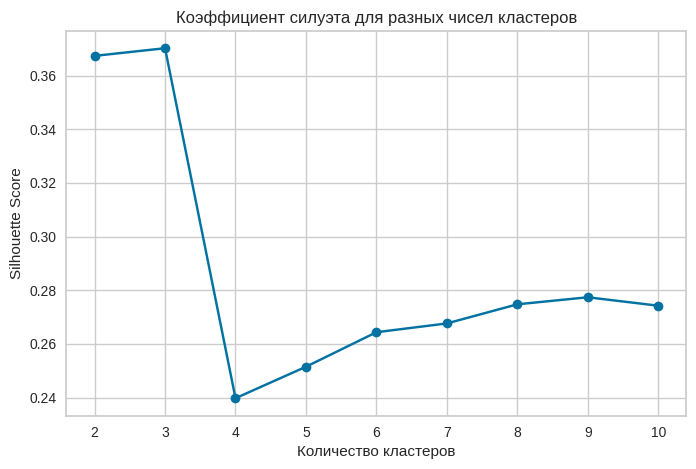

Оптимальное количество кластеров по силуэту: 3


In [ ]:
silhouette_scores = []

for n in range(2, 11):
    model = AgglomerativeClustering(n_clusters=n)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Коэффициент силуэта для разных чисел кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_n = np.argmax(silhouette_scores) + 2
print(f"Оптимальное количество кластеров по силуэту: {best_n}")


Увидели, что в данном случае лучшее знаение коэффициента силуэта достигается при числе кластеров, равном 3 ( в отличие от предыдущего анализа, где мы получили 4 ).

Строим дендраграмму, чтобы наглядно увидеть деление на кластеры

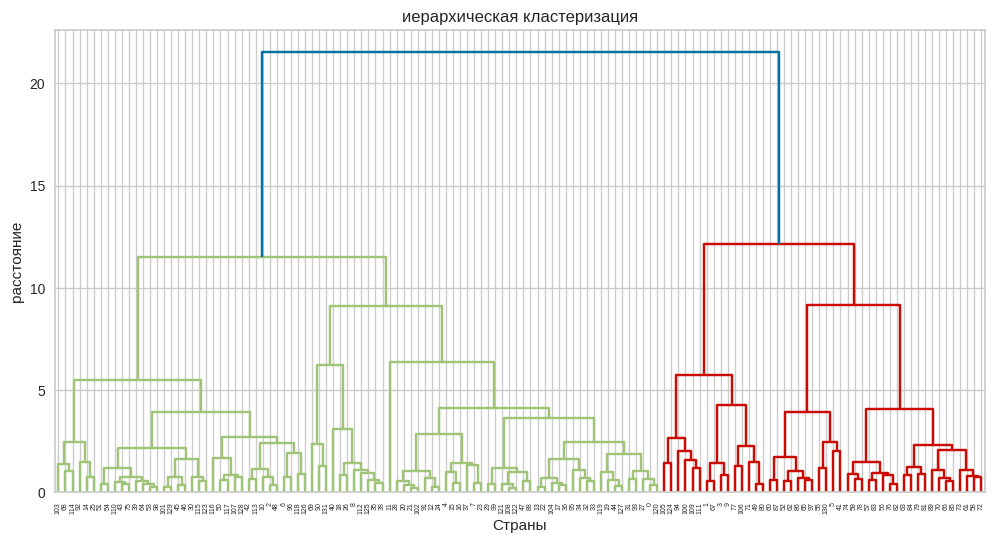

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('иерархическая кластеризация')
plt.xlabel('Страны')
plt.ylabel('расстояние')
plt.show()

Запускаем финальную модель с тремя кластерами.

In [ ]:
agg = AgglomerativeClustering(n_clusters=best_n, linkage='ward')
cluster_labels_agg = agg.fit_predict(X_scaled)

cluster_data_clean['Clusters_hierarchical'] = cluster_labels_agg

Посмотрим, что получилось и сравним с полученным через k-means:

In [ ]:
cluster_data_clean["Clusters_hierarchical"].value_counts()

,count
Clusters_hierarchical,
0,86
1,31
2,15


In [ ]:
cluster_data_clean.groupby('Clusters_hierarchical')[selected_variables].mean(numeric_only=True)

,"Gross expenditure on R&D, % GDP_2022",Ecological sustainability_2022,"Pupil-teacher ratio, secondary_2022",Political and operational stability_2022,"Creative goods exports, % total trade_2022"
Clusters_hierarchical,,,,,
0,6.443023,22.950000,60.754651,63.088372,5.060465
1,37.841935,44.341935,88.261290,79.119355,15.941935
2,23.120000,35.733333,80.440000,77.320000,80.253333


Заметим, что у нас все еще осталось деление на группу развитых стран с лидирующей долей креативных товаров в экспорте, группу развитых стран, ориентирующихся на научно-технический прогресс ( большие вклады в его развитие ) и остающие. Но в данном случае отстающие не делятся на группы с хорошей и плохой нагрузкой на образовательную систему (по pupil-teacher ratio), кластеры 0 и 3 из нашего предыдущего анализа здесь объединились в одну группу. Получается, иерархический метод выделил более обобщённую структуру, сгруппировав страны по основным направлениям развития.

Теперь сделаем с помощью DBSCAN:

In [ ]:
eps_values = np.arange(0.2, 3.2, 0.2)
min_samples = np.arange(2, 10)
results = []
for eps, min_s in product(eps_values, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_s)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = 0
    results.append((eps, min_s, n_clusters, sil))
results_df = pd.DataFrame(results, columns=['eps', 'min_samples', 'n_clusters', 'silhouette'])

Строим тепловые карты числа кластеров и числа силуэта при различных eps и min_samples.

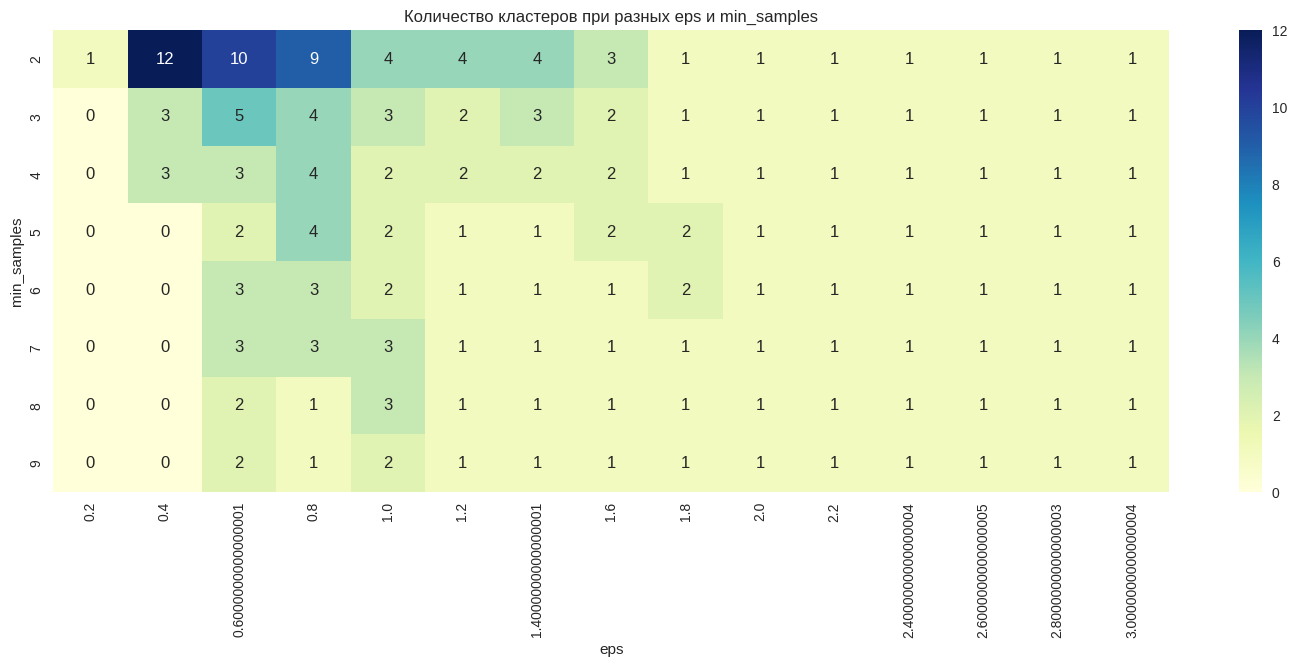

In [ ]:
pivot_n = results_df.pivot(index='min_samples', columns='eps', values='n_clusters')

plt.figure(figsize=(18, 6))
sns.heatmap(pivot_n, annot=True, cmap='YlGnBu')
plt.title('Количество кластеров при разных eps и min_samples')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.show()

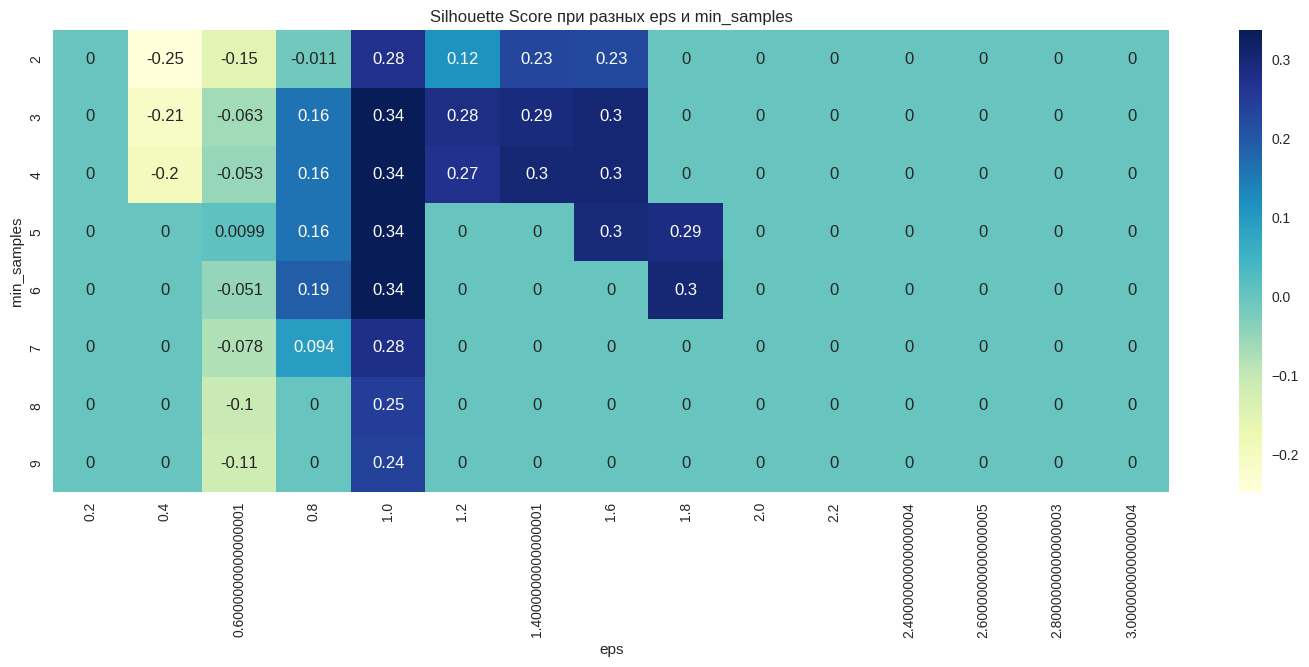

In [ ]:
pivot_sil = results_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(18, 6))
sns.heatmap(pivot_sil, annot=True, cmap='YlGnBu')
plt.title('Silhouette Score при разных eps и min_samples')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.show()

Максимум составляет 0.34 при eps = 1 и min_samples от 3 до 6. Число кластеров при этих значениях от 2 до 3. Учитывая предыдущие результаты ( k-means и иерархический ) понимаем, что скорее всего 2 кластеров для хорошего деления не подойдет. Возьмем 3 кластера ( eps = 1, min_samples = 3 )

Запускаем модель и смотрим, что получилось:

In [ ]:
dbscan = DBSCAN(eps=1, min_samples=3)
labels_db = dbscan.fit_predict(X_scaled)
cluster_data_clean['Clusters_DBSCAN'] = labels_db

In [ ]:
cluster_data_clean["Clusters_DBSCAN"].value_counts()

,count
Clusters_DBSCAN,
0,77
2,28
-1,23
1,4


In [ ]:
cluster_data_clean.groupby('Clusters_DBSCAN')[selected_variables].mean(numeric_only=True)

,"Gross expenditure on R&D, % GDP_2022",Ecological sustainability_2022,"Pupil-teacher ratio, secondary_2022",Political and operational stability_2022,"Creative goods exports, % total trade_2022"
Clusters_DBSCAN,,,,,
-1,29.204348,30.613043,64.991304,74.139130,42.647826
0,4.942857,21.984416,62.627273,62.128571,5.092208
1,25.125000,50.125000,88.875000,82.250000,94.825000
2,32.900000,45.960714,89.107143,79.285714,13.603571


In [ ]:
cluster_data_clean[cluster_data_clean["Clusters_DBSCAN"] == 1]["Country"]

,Country
1,Czechia
3,"Hong Kong SAR, China"
10,Slovak Republic
72,Hungary


Мы видим, что на группы поделилось аналогично логике в случае с иерархическим методом, только здесь очень сильно выделяется кластер стран-экспортёров культурных товаров. Во-первых здесь их мало ( всего 4 и это Чехия, Китай, Словакия и Венгрия ), а во вторых средняя доля экспорта креативных товаров больше: 94.8%. ( в k-means и иерархическом было 80% и 88% ). Также даже с min_samples = 3, достаточно много (23 страны) посчитались выбросами ( аномальными/не принадлежащими к каким-то кластерам ).

Получается, что DBSCAN показал более избирательное разделение: он выделил небольшую, но очень однородную группу стран с экстремально высокой долей креативного экспорта и отнёс многие другие страны к выбросам. То есть распределение признаков неоднородно и не все страны образуют достаточно плотные кластеры, чтобы быть уверенно выделенными.

# Общий итог

В итоге, все три метода — K-means, иерархическая кластеризация и DBSCAN — показали примерно одинаковую картину.
Иерархический метод и DBSCAN разделили страны на три основные группы: развитые инновационные экономики, страны с развитым креативным экспортом и менее развитые государства. При этом DBSCAN оказался более чувствительным — он нашёл те же кластеры, но отметил много стран как выбросы, то есть тех, кто не вписывается ни в одну из групп.

Метод K-means разделил данные чуть подробнее — на четыре кластера, добавив отдельную группу стран, которые отличаются по нагрузке в системе образования (pupil–teacher ratio).

В целом все методы показали, что страны действительно различаются по уровню инновационного развития: есть лидеры с развитыми технологиями и устойчивой экономикой, государства с акцентом на креативный экспорт, и страны, где инновации пока находятся на начальной стадии.